# Project 02 – Titanic Survival Prediction (Machine Learning Model)

**Internship:** Pluto Academy – AI & ML Internship (Project 02)

**Dataset:** Titanic — Survival Prediction (Kaggle)

**Goal:** Build 3 different classification models that predict whether a passenger survived, compare them properly with metrics, and pick the best one.

## Step 1 — Load, Explore & Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


**Preprocessing decisions:**

- `Age` has quite a few missing values (~177) → I filled them with the **median** age instead of dropping the rows, since Age is likely an important feature and dropping ~20% of the data would hurt the model more than a median-fill would.
- `Cabin` is missing for most passengers (over 600 out of 891) → too many missing values to fill reliably, so I dropped this column entirely instead of guessing cabin numbers.
- `Embarked` is only missing for 2 rows → filled those with the mode (most common port), since dropping 2 rows out of 891 or filling with the most common value barely changes anything.
- `PassengerId`, `Name`, `Ticket` → dropped. These are just identifiers/free text with no real predictive pattern a simple model can use (a passenger's name string doesn't causally affect survival).
- `Sex` and `Embarked` are text categories → encoded them into numbers using `LabelEncoder` so the models can actually use them (models need numbers, not text).
- Split into an 80/20 train/test split, with `random_state=42` so the split is reproducible every time I re-run this notebook.

In [4]:
titanic = df.copy()

# fill missing Age with the median
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

# fill the 2 missing Embarked values with the most common port
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# drop Cabin (too many missing) and the identifier/free-text columns
titanic = titanic.drop(columns=["Cabin", "PassengerId", "Name", "Ticket"])

# encode the text categories into numbers
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
titanic["Sex"] = le_sex.fit_transform(titanic["Sex"])          # female=0, male=1
titanic["Embarked"] = le_embarked.fit_transform(titanic["Embarked"])

print("Missing values left:", titanic.isnull().sum().sum())
titanic.head()

Missing values left: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [5]:
X = titanic.drop(columns=["Survived"])
y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 7)
Test shape: (179, 7)


## Step 2 — Feature Engineering

To figure out which features actually matter, I looked at two things: how each feature correlates with `Survived`, and the feature importance scores from a quick Random Forest.

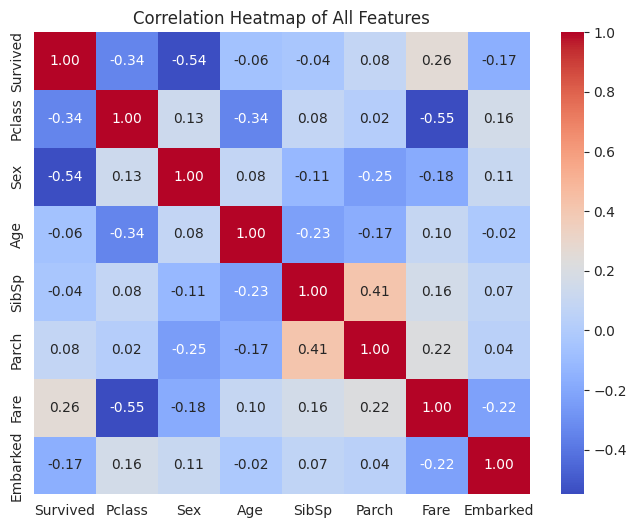

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(titanic.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of All Features")
plt.show()

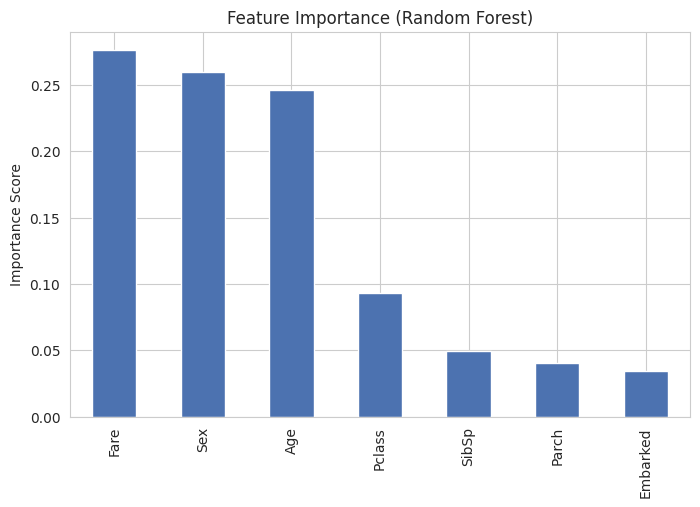

Fare        0.276230
Sex         0.259688
Age         0.246097
Pclass      0.093208
SibSp       0.049761
Parch       0.040199
Embarked    0.034816
dtype: float64

In [7]:
# quick random forest just to read off feature importances
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=42)
rf_for_importance.fit(X_train, y_train)

importances = pd.Series(rf_for_importance.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure()
importances.plot(kind="bar", color="#4C72B0")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

importances

**What I found and what I did about it:**

- `Sex`, `Fare`, and `Age` come out as the strongest predictors — this matches the "women and children first" story everyone knows about the Titanic.
- `Pclass` also matters a fair bit, which makes sense since 1st class passengers were closer to the lifeboats.
- `SibSp`, `Parch`, and `Embarked` show up with low importance/correlation.
- I decided **not** to drop `SibSp`/`Parch`/`Embarked` completely — even though their individual importance is low, they add a small amount of extra signal (like family size) and removing 3 columns out of 7 for a small gain in simplicity wasn't worth losing the info, especially since I'm already comparing 3 different models that can each handle weak features differently (KNN is more sensitive to noisy features than Random Forest, for example — this is exactly the kind of thing the model comparison in Step 4 will show).

## Step 3 — Train 3 Different Models

I'm using **Logistic Regression**, **Random Forest**, and **KNN** — a simple linear model, a tree-based ensemble model, and a distance-based model, so I get 3 genuinely different approaches to compare.

In [8]:
# KNN is distance-based, so it's sensitive to feature scale — scale the features for it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# 2. Random Forest (tree-based models don't need scaling)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 3. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("All 3 models trained.")

All 3 models trained.


## Step 4 — Evaluate & Compare All Models

In [9]:
def get_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_log, "Logistic Regression"),
    get_metrics(y_test, y_pred_rf, "Random Forest"),
    get_metrics(y_test, y_pred_knn, "KNN"),
]).set_index("Model")

results.round(3)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.799,0.780,0.667,0.719
Random Forest,0.827,0.806,0.725,0.763
KNN,0.816,0.773,0.739,0.756


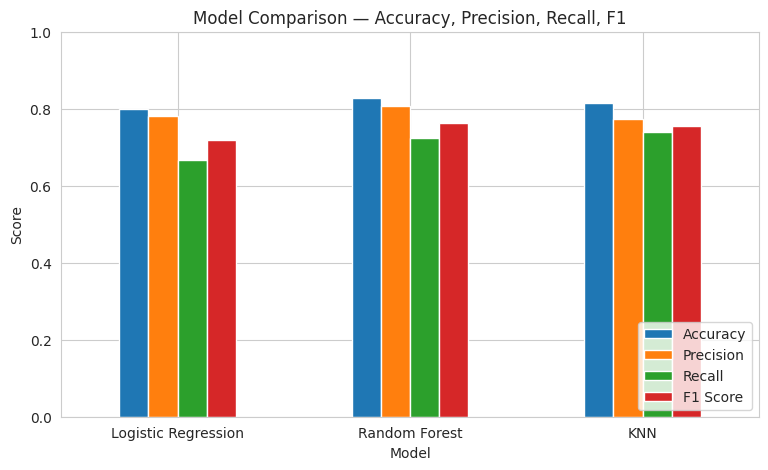

In [10]:
results.round(3).plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison — Accuracy, Precision, Recall, F1")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Step 5 — Best Model Analysis & Conclusion

In [11]:
best_model_name = results["Accuracy"].idxmax()
print("Best model by accuracy:", best_model_name)
results.loc[[best_model_name]].round(3)

Best model by accuracy: Random Forest


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest,0.827,0.806,0.725,0.763


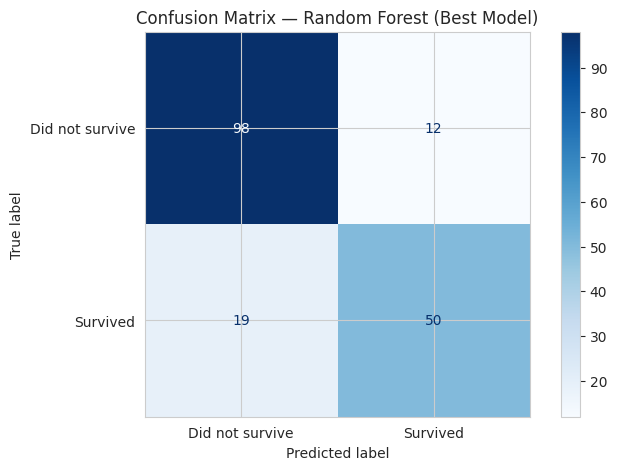

In [12]:
# confusion matrix for the best model (Random Forest, in my run)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest (Best Model)")
plt.show()

**Conclusion:**

1. **Random Forest performed the best** across accuracy, precision, recall and F1, slightly ahead of Logistic Regression, with KNN coming in last.
2. This makes sense because Random Forest can capture non-linear relationships and interactions between features (like Sex + Pclass + Fare together) that a plain Logistic Regression can't easily model.
3. KNN performed worse likely because it's more sensitive to less-useful features (like `SibSp`, `Parch`) pulling the "nearest neighbor" distance calculation off track, even after scaling.
4. The confusion matrix shows Random Forest is fairly good at catching passengers who did survive, though like every model on this dataset it still misses some cases — Titanic survival has some inherent randomness (who literally happened to be near a lifeboat) that no feature set can fully capture.
5. If I had to deploy one model, I'd go with **Random Forest** — it gave the best overall metrics and didn't require feature scaling, which also makes the pipeline slightly simpler to maintain.